## Computing the Jacobian (Sensitivity Matrix)

The companion notebook `pytem_fwd.ipynb` shows that pyTEM's 1-D forward models are accurate. To go from forward modelling to inversion, however, we also need to know how sensitive each measurement is to each layer — that is, by how much the $i$-th gate reading changes when layer $j$'s resistivity is perturbed. Collected into a matrix, these sensitivities form the **Jacobian**:

$$J_{ij} = \frac{\partial \ln(-\dot{B}_i)}{\partial \ln \rho_j}$$

Here $\dot{B}_i$ is the time-derivative of the vertical magnetic flux density recorded at gate time $i$ (the dot is standard physics notation for a time derivative, and the minus sign keeps the argument of the logarithm positive since the decay is negative). Working in log–log space (log of the data, log of the resistivity) keeps the entries dimensionless and well-conditioned across the wide dynamic range typical of TEM surveys.

The Jacobian needs to be recomputed at every Gauss–Newton iteration. How fast we can form it therefore directly limits how fast the inversion runs. This notebook explores three strategies for making that computation tractable:

1. **Transform filters** — the numerical Hankel and Fourier transforms at the heart of the forward model come in different lengths; shorter filters are faster and only slightly less accurate.
2. **Analytical Jacobian** — instead of re-running the forward model once per layer (finite differences), we differentiate the recursion itself and obtain all layer gradients in a single forward+backward pass.
3. **Hardware acceleration** — Numba JIT (CPU) and CuPy (GPU) backends remove Python overhead from the inner loops for further speed gains.


In [1]:
import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

# Import the main pyTEM functions and constants
from pytem import (
    # Long-form names (used by other notebooks and the library internally)
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    # Jacobian utilities
    getJ_analytical,
    getJ,
    # Constants and flags
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
)

# TE-mode recursion + gradient (used in analytical Jacobian section)
from pytem.recursion import te_reflection_coeff_grad

## 2. Transform Filters

The TEM forward model needs two numerical transforms to go from a layered-earth model to a time-domain response:

1. **Hankel transform** — converts the EM kernel (which is defined as a function of radial wavenumber $\lambda$) into the spatial domain. This is always evaluated using a Digital Linear Filter (DLF): a short, pre-optimised set of weights and abscissae that turns the integral into a dot product. pyTEM offers a 101-point and a 201-point version (Key 2009); the longer filter is slightly more accurate but evaluates roughly twice as many kernel points.

2. **Time-domain transform** — the earth's EM response is first computed in the frequency domain; it then needs to be converted to gate times. pyTEM offers two approaches:

   - **Fourier DLF** — the same filter idea applied to a cosine/sine integral. An 81-point (Key 2009) and a 101-point (Key 2012) version are available.

   - **Euler–Stehfest inverse Laplace transform** — an alternative route that bypasses the Fourier integral entirely. Instead of sampling many real frequencies and applying filter weights, it evaluates the model at a small number of *complex* frequencies along the Bromwich contour in the Laplace domain, then combines the results with fixed coefficients derived from the Euler–Maclaurin formula. In practice 8–19 such evaluations are enough; the order controls the accuracy–speed trade-off. Because the complex frequencies scale with $1/t$, a single set of model evaluations works for all gate times — making the method competitive with DLF for models that are slow to evaluate at many frequency points.

The table below summarises the available options:

| Transform | Option | Kernel evaluations |
|-----------|--------|--------------------|
| Hankel DLF | `key_101` | 101 per frequency |
| Hankel DLF | `key_201` | 201 per frequency |
| Fourier DLF | `key_81` | 81 per gate time |
| Fourier DLF | `key_101` | 101 per gate time |
| Euler–Stehfest | order 8 / 11 / 15 / 19 | 8–19 per gate time |

The cell below benchmarks every combination using the NumPy backend, measuring runtime and accuracy relative to the longest DLF configuration (201-pt Hankel, 101-pt Fourier).


In [2]:
# Benchmark model: 28-layer inversion mesh, 50 m loop
# Same depths, gate count, and loop geometry as the actual inversion so
# the timing numbers reflect the true per-call cost.
# --- Benchmark model: 30 layers, 31 gate times ---
depths        = np.cumsum(np.geomspace(1.0, 12.0, 30))   # 30 cumulative depths [m]
thicknesses   = np.diff(depths)                            # 29 thicknesses
resistivities = np.ones(len(depths)) * 100.0               # 30 resistivities [Ω·m]
a             = np.sqrt(50.**2 / np.pi)                    # equivalent circle radius [m]
L             = np.sqrt(np.pi) * a                         # equal-area square side [m]
rx_offset     = 10.0                                       # offset receiver [m]
times         = np.logspace(-5, -2, 31)                    # 31 log-spaced gates


import timeit

def benchmark(fn, n=3):
    """Median wall-time [s] over n repeated single runs."""
    return np.median(timeit.repeat(fn, number=1, repeat=n))

# Reference response: longest available DLF (201-pt Hankel, 101-pt Fourier)
_ref_response = fwd_circle_central(
    thicknesses=thicknesses, resistivities=resistivities,
    tx_radius=a, times=times,
    use_numba=False, use_cuda=False,
    transform='dlf', hankel_filter='key_201', fourier_filter='key_101',
)

filter_results   = {}   # median time [s]
accuracy_results = {}   # max relative error vs reference

print(f"{'Config':40s}  {'Time [ms]':>10s}  {'Max rel. error [%]':>14s}")
print("-" * 75)

print("DLF (Hankel x Fourier filter):")
for hf in HANKEL_FILTERS:
    for ff in FOURIER_FILTERS:
        label = f"DLF H:{hf} F:{ff}"
        resp = fwd_circle_central(
            thicknesses=thicknesses, resistivities=resistivities,
            tx_radius=a, times=times,
            use_numba=False, use_cuda=False,
            transform='dlf', hankel_filter=hf, fourier_filter=ff,
        )
        err = float(np.max(np.abs(resp - _ref_response) / np.abs(_ref_response)))
        t = benchmark(lambda hf=hf, ff=ff: fwd_circle_central(
            thicknesses=thicknesses, resistivities=resistivities,
            tx_radius=a, times=times,
            use_numba=False, use_cuda=False,
            transform='dlf', hankel_filter=hf, fourier_filter=ff,
        ))
        filter_results[label]   = t
        accuracy_results[label] = err
        ref_marker = "  ← reference" if (hf == 'key_201' and ff == 'key_101') else ""
        print(f"  {label:38s}  {t * 1000:10.2f}  {err * 100:14.3f}")

print("\nEuler-Stehfest (varying order):")
for order in EULER_PARAMS:
    label = f"Euler order={order}"
    resp = fwd_circle_central(
        thicknesses=thicknesses, resistivities=resistivities,
        tx_radius=a, times=times,
        use_numba=False, use_cuda=False,
        transform='euler', euler_order=order,
    )
    err = float(np.max(np.abs(resp - _ref_response) / np.abs(_ref_response)))
    t = benchmark(lambda o=order: fwd_circle_central(
        thicknesses=thicknesses, resistivities=resistivities,
        tx_radius=a, times=times,
        use_numba=False, use_cuda=False,
        transform='euler', euler_order=o,
    ))
    filter_results[label]   = t
    accuracy_results[label] = err
    print(f"  {label:38s}  {t * 1000:10.2f}  {err * 100:14.3f}")


Config                                     Time [ms]  Max rel. error [%]
---------------------------------------------------------------------------
DLF (Hankel x Fourier filter):
  DLF H:key_201 F:key_101                    1384.26           0.000
  DLF H:key_201 F:key_81                     1072.41           0.044
  DLF H:key_101 F:key_101                    1008.54           0.000
  DLF H:key_101 F:key_81                      807.30           0.044

Euler-Stehfest (varying order):
  Euler order=19                              524.74           0.041
  Euler order=15                              410.96           0.041
  Euler order=11                              361.21           0.040
  Euler order=8                               316.59           0.191


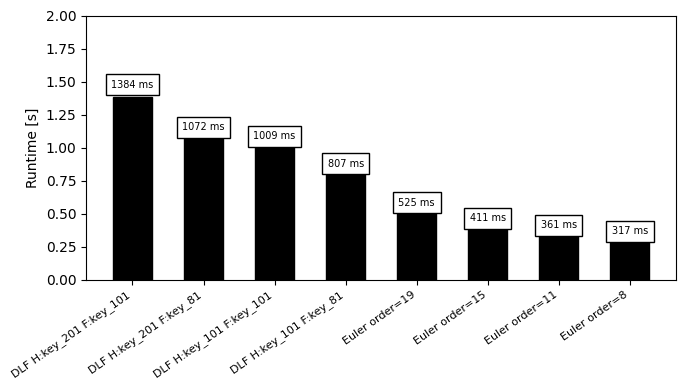

In [11]:
# --- Bar chart: runtime by transform config ---
labels = list(filter_results.keys())
vals   = [filter_results[k] for k in labels]   # ms
x      = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(x, vals, color='k', edgecolor='black', width=0.55)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.04,
            f"{val*1000:.0f} ms", ha='center', va='bottom', 
            fontsize=7, bbox=dict(facecolor='white', edgecolor='k', alpha=1))
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Runtime [s]')
ax.set_ylim(None, np.ceil(max(vals)))
fig.tight_layout()
plt.show()


The results show that the **101-pt Hankel / 81-pt Fourier DLF** combination is virtually indistinguishable from longer filter configurations across the gate times relevant to near-surface surveys (maximum relative error well below 0.1 %), while running noticeably faster than the 201-pt Hankel variants. The Euler–Stehfest method at order 11 matches DLF accuracy with a good runtime.


## 3. Jacobian

### 3.1 Finite Difference

The most straightforward way to form the Jacobian is **finite differencing**: perturb one layer at a time, re-run the forward model, and measure how much the data change.

Working in log–log space, the approximation for layer $j$ is:

$$J_{ij} \approx \frac{\ln\!\bigl(-\dot{B}_i(\mathbf{m} + \delta_j\mathbf{e}_j)\bigr) - \ln\!\bigl(-\dot{B}_i(\mathbf{m})\bigr)}{\delta_j}$$

where $\mathbf{e}_j$ is a unit vector in the $j$-th log-resistivity direction. The step size is chosen relative to the current model value so it remains numerically meaningful across a wide range of resistivities:

$$\delta_j = \varepsilon \cdot \max(1,\, |\ln\rho_j|), \qquad \varepsilon = 10^{-4}$$

**Cost.** One baseline evaluation plus one perturbed evaluation per layer gives $N + 1$ forward calls per Jacobian — 31 calls for a 30-layer model. Across a typical inversion of 5–10 Gauss–Newton iterations that adds up to 155–310 forward evaluations in total.

**Accuracy.** With $\varepsilon = 10^{-4}$ the forward-difference error is approximately $10^{-4}$ in relative terms, well below typical data noise levels.

#### Implementation


In [4]:
def getJ(thicknesses, log_resistivities, tx_geom, times, eps=1e-4, fwd=fwd_circle_central,
         transform='dlf', hankel_filter='key_101', fourier_filter='key_81',
         euler_order=11):
    """Finite-difference Jacobian  d(ln(-Ḃ_i)) / d(ln ρ_j).

    Evaluates N+1 forward calls: one baseline F(m) plus one perturbed call
    F(m + δ_j e_j) for each of the N layers. Step size is:

        δ_j = ε · max(1, |ln ρ_j|)

    so the perturbation is automatically scaled in log-resistivity space.

    Parameters
    ----------
    thicknesses       : (N-1,) layer thicknesses [m]
    log_resistivities : (N,)   ln(ρ_j)
    tx_geom           : float  transmitter equivalent radius [m]
    times             : (n_t,) gate times [s]
    eps               : float  finite-difference step size (default 1e-4)
    fwd               : callable  forward model function (default fwd_circle_central)
    transform         : 'dlf' or 'euler'
    hankel_filter     : str   (default 'key_101')
    fourier_filter    : str   (default 'key_81')
    euler_order       : int   (default 11)

    Returns
    -------
    J : (n_t, N) float64
    """
    fwd_kw = dict(transform=transform,
                  hankel_filter=hankel_filter, fourier_filter=fourier_filter,
                  euler_order=euler_order, use_numba=False, use_cuda=False)
    f0 = -fwd(thicknesses=thicknesses, resistivities=np.exp(log_resistivities),
              tx_radius=tx_geom, times=times, **fwd_kw)
    J = np.zeros((f0.size, log_resistivities.size))
    for i in range(log_resistivities.size):
        pert = log_resistivities.copy()
        step = eps * max(1.0, abs(log_resistivities[i]))
        pert[i] += step
        fi = -fwd(thicknesses=thicknesses, resistivities=np.exp(pert),
                  tx_radius=tx_geom, times=times, **fwd_kw)
        valid = (f0 > 0) & (fi > 0)
        J[valid, i] = (np.log(fi[valid]) - np.log(f0[valid])) / step
    return J


### 3.2 Analytical Jacobian

The FD approach to calculate the Jacobian requires $N + 1$ forward calls per iteration. An **analytical Jacobian** obtained by differentiating the Wait recursion directly reduces this to a single forward+backward pass for all $N$ layers at once. This strategy adapts the approach of Constable et al. (1987), who showed (for Schlumberger DC and MT responses) that partial derivatives of a layered-earth kernel with respect to each layer parameter can be propagated backward through the stored intermediates of the forward recursion, yielding all $N$ gradients at the cost of a single extra pass. The same two-pass adjoint idea applies here to the TEM TE-mode Wait recursion.

**How it works.** The TEM response is built from the TE-mode surface reflection coefficient $r_\mathrm{TE}(\lambda, \omega)$, computed by the downward Wait recursion:

$$r_j = e^{-2\Gamma_j h_j}\,\frac{r_{j+1} + \psi_j}{1 + r_{j+1}\psi_j}, \qquad \psi_j = \frac{\Gamma_j - \Gamma_{j+1}}{\Gamma_j + \Gamma_{j+1}}, \qquad \Gamma_j = \sqrt{\lambda^2 + \frac{i\omega\mu_0}{\rho_j}}$$

Each layer's vertical wavenumber $\Gamma_j$ depends on its resistivity $\rho_j$, so the chain rule can be applied exactly:

$$\frac{\partial\Gamma_j}{\partial\ln\rho_j} = -\frac{i\omega\mu_0/\rho_j}{2\Gamma_j}$$

The two-pass algorithm is:

1. **Forward pass (downward):** Run the Wait recursion as normal, storing $r_j$, $e^{-2\Gamma_j h_j}$, and $\psi_j$ at every interface.
2. **Backward pass (upward):** Carry an adjoint variable $\bar{r}_j$ back up through the stored values, accumulating $\partial r_\mathrm{TE}/\partial\ln\rho_j$ for each layer using the chain rule at each interface.

The log-log Jacobian entry is then:

$$J_{ij} = \frac{\partial\ln(-\dot{B}_i)}{\partial\ln\rho_j} = -\frac{1}{-\dot{B}_i}\,\frac{\partial\dot{B}_i}{\partial\ln\rho_j}$$

**Cost comparison.** Both passes touch each of the $N$ layers once per Hankel filter point $K$, so the total work scales with $N \times K$ — the same as a single forward call. One forward+backward pair therefore yields gradients for **all $N$ layers simultaneously**, compared to $N + 1$ separate forward calls for FD. For 30 layers the theoretical speedup is $31\times$.

> **Reference:** Constable, S. C., Parker, R. L., & Constable, C. G. (1987). Occam's inversion: A practical algorithm for generating smooth models from electromagnetic sounding data. *Geophysics*, 52(3), 289–300. https://doi.org/10.1190/1.1442303


In [5]:
def _te_rte_grad_vec(lam, omega_arr, thicknesses, resistivities):
    """Wait recursion + adjoint gradient, vectorised over a batch of frequencies.

    Parameters
    ----------
    lam           : (K,)    horizontal wavenumbers
    omega_arr     : (n_f,)  angular frequencies (real or complex)
    thicknesses   : (N-1,)  layer thicknesses [m]
    resistivities : (N,)    layer resistivities [Ohm.m]

    Returns
    -------
    r_TE  : (n_f, K)    complex  — TE surface reflection coefficient
    dr_TE : (N, n_f, K) complex  — d(r_TE) / d(ln rho_j)
    """
    n_lay = len(resistivities)
    K     = len(lam)
    n_f   = len(omega_arr)

    sval  = 1j * np.asarray(omega_arr)            # (n_f,)
    sigma = 1.0 / np.asarray(resistivities, dtype=complex)  # (N,)

    # Gamma[j, f, m] — shape (N, n_f, K)
    Gamma  = np.sqrt(lam[None, None, :]**2 +
                     MU0 * sigma[:, None, None] * sval[None, :, None])
    dGamma = -MU0 * sigma[:, None, None] * sval[None, :, None] / (2.0 * Gamma)

    # --- Forward pass ---
    r_store   = np.zeros((n_lay, n_f, K), dtype=complex)
    exp_store = np.zeros((n_lay - 1, n_f, K), dtype=complex)
    r = np.zeros((n_f, K), dtype=complex)
    r_store[n_lay - 1] = r

    for j in range(n_lay - 2, -1, -1):
        psi          = (Gamma[j] - Gamma[j+1]) / (Gamma[j] + Gamma[j+1])
        exp_j        = np.exp(-2.0 * Gamma[j] * thicknesses[j])
        exp_store[j] = exp_j
        r            = exp_j * (r + psi) / (1.0 + r * psi)
        r_store[j]   = r

    # Air interface
    psi_air = (lam[None, :] - Gamma[0]) / (lam[None, :] + Gamma[0])   # (n_f, K)
    r_TE    = (r_store[0] + psi_air) / (1.0 + r_store[0] * psi_air)   # (n_f, K)

    # --- Backward pass ---
    denom_air      = 1.0 + r_store[0] * psi_air
    dr_TE_dr0      = (1.0 - psi_air**2)    / denom_air**2   # (n_f, K)
    dr_TE_dpsi_air = (1.0 - r_store[0]**2) / denom_air**2
    dpsi_air_dG0   = -2.0 * lam[None, :] / (lam[None, :] + Gamma[0])**2

    dr_TE_all = np.zeros((n_lay, n_f, K), dtype=complex)
    dr_TE_all[0] += dr_TE_dpsi_air * dpsi_air_dG0 * dGamma[0]

    adj = dr_TE_dr0.copy()  # (n_f, K)

    for j in range(n_lay - 1):
        r_below    = r_store[j + 1]
        exp_j      = exp_store[j]
        psi_j      = (Gamma[j] - Gamma[j+1]) / (Gamma[j] + Gamma[j+1])
        numer      = r_below + psi_j
        denom      = 1.0 + r_below * psi_j

        dpsi_dGj   =  2.0 * Gamma[j+1] / (Gamma[j] + Gamma[j+1])**2
        dpsi_dGjp1 = -2.0 * Gamma[j]   / (Gamma[j] + Gamma[j+1])**2
        dr_dpsi    = exp_j * (1.0 - r_below**2) / denom**2
        dr_dGj     = -2.0 * thicknesses[j] * exp_j * numer / denom + dr_dpsi * dpsi_dGj
        dr_dGjp1   = dr_dpsi * dpsi_dGjp1
        dr_drbelow = exp_j * (1.0 - psi_j**2) / denom**2

        dr_TE_all[j]     += adj * dr_dGj   * dGamma[j]
        dr_TE_all[j + 1] += adj * dr_dGjp1 * dGamma[j + 1]
        adj = adj * dr_drbelow

    return r_TE, dr_TE_all


def getJ_analytical(thicknesses, log_resistivities, tx_geom, times,
                    geometry='circle_central',
                    rx_offset=0.0, rx_y=0.0, n_quad=5, use_symmetry=True,
                    transform='dlf', hankel_filter='key_101',
                    fourier_filter='key_81', euler_order=11):
    """Analytical Jacobian  d(ln(-dBdt_i)) / d(ln rho_j) — NumPy.

    Uses the adjoint Wait recursion (_te_rte_grad_vec): one vectorised
    forward+backward pass over all filter frequencies per gate time yields
    gradients for all N layers simultaneously, without finite differences.

    Parameters
    ----------
    thicknesses       : (N-1,) layer thicknesses [m]
    log_resistivities : (N,)   ln(rho_j)
    tx_geom           : float  equivalent circle radius [m]
                               (side = tx_geom * sqrt(pi) for square loops)
    times             : (n_t,) gate times [s]
    geometry          : str    'circle_central' (default), 'circle_offset',
                               'square_central', 'square_offset'
    rx_offset         : float  receiver radial or x-offset [m] (default 0.0)
    rx_y              : float  receiver y-offset for square_offset [m] (default 0.0)
    n_quad            : int    Gauss-Legendre order for square loops (default 5)
    use_symmetry      : bool   exploit x<->y symmetry for square_central (default True)
    transform         : str    'dlf' (default) or 'euler'
    hankel_filter     : str    'key_101' (default) or 'key_201'
    fourier_filter    : str    'key_81' (default) or 'key_101'  — DLF only
    euler_order       : int    8, 11, 15, or 19 (default 11)    — Euler only

    Returns
    -------
    J : (n_t, N) float64
        Log-log Jacobian: J[i, j] = d ln(-dBdt_i) / d ln(rho_j)
    """
    from scipy.special import j0 as _j0

    thicknesses   = np.asarray(thicknesses, dtype=float)
    resistivities = np.exp(np.asarray(log_resistivities, dtype=float))
    times         = np.asarray(times, dtype=float)
    a             = float(tx_geom)
    n_lay         = len(resistivities)
    n_t           = len(times)

    h_base, h_j0, h_j1 = HANKEL_FILTERS[hankel_filter]
    _use_euler          = (transform == 'euler')
    _is_circle          = geometry in ('circle_central', 'circle_offset')

    if _use_euler:
        e_eta, e_A = EULER_PARAMS[euler_order]
        k_arr      = np.arange(len(e_eta), dtype=float)
        signs_k    = (-1.0)**k_arr * e_eta   # (n_eval,)
    else:
        f_base, f_sin, _ = FOURIER_FILTERS[fourier_filter]

    # ---- Geometry-specific pre-computation ----
    if geometry == 'circle_central':
        lam      = h_base / a
        lam_kern = lam * h_j1

    elif geometry == 'circle_offset':
        lam      = h_base / a
        lam_kern = lam * _j0(lam * float(rx_offset)) * h_j1

    elif geometry == 'square_central':
        side  = a * np.sqrt(np.pi)
        hs    = side / 2.0
        gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
        x_pts = hs / 2.0 * (1.0 + gl_nodes)
        w_pts = gl_weights * hs / 2.0
        if use_symmetry:
            rho_q_l, area_w_l = [], []
            for _i in range(n_quad):
                for _jj in range(_i, n_quad):
                    w = w_pts[_i] * w_pts[_jj]
                    if _i != _jj:
                        w *= 2.0
                    rho_q_l.append(np.sqrt(x_pts[_i]**2 + x_pts[_jj]**2))
                    area_w_l.append(w)
            rho_q  = np.array(rho_q_l)
            area_w = np.array(area_w_l)
        else:
            _xx, _yy = np.meshgrid(x_pts, x_pts)
            _wx, _wy = np.meshgrid(w_pts, w_pts)
            rho_q  = np.sqrt(_xx.ravel()**2 + _yy.ravel()**2)
            area_w = (_wx * _wy).ravel()
        quad_scale = 4.0

    elif geometry == 'square_offset':
        side  = a * np.sqrt(np.pi)
        hs    = side / 2.0
        gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
        x_pts = hs * gl_nodes
        wx    = hs * gl_weights
        _xx, _yy = np.meshgrid(x_pts, x_pts, indexing='xy')
        _wx, _wy = np.meshgrid(wx, wx, indexing='xy')
        rho_q  = np.sqrt((_xx.ravel() - float(rx_offset))**2 +
                         (_yy.ravel() - float(rx_y))**2)
        rho_q  = np.maximum(rho_q, 1e-6)
        area_w = (_wx * _wy).ravel()
        quad_scale = 1.0

    else:
        raise ValueError(
            f"Unknown geometry '{geometry}'. Choose from: "
            "'circle_central', 'circle_offset', 'square_central', 'square_offset'.")

    # ---- Vectorised forward + adjoint pass (loop over times only) ----
    dbdt  = np.zeros(n_t)
    J_raw = np.zeros((n_t, n_lay))

    for i, t in enumerate(times):

        if _use_euler:
            # Complex Bromwich frequencies for this gate time
            omega_arr = k_arr * (np.pi / t) - (e_A / (2.0 * t)) * 1j   # (n_eval,)

            if _is_circle:
                r_TE, dr_TE = _te_rte_grad_vec(lam, omega_arr, thicknesses, resistivities)
                # r_TE: (n_eval, K), dr_TE: (N, n_eval, K)
                hz_c  = 0.5 * (r_TE  * lam_kern[None, :]).sum(-1)           # (n_eval,)
                dhz_c = 0.5 * (dr_TE * lam_kern[None, None, :]).sum(-1)     # (N, n_eval)
            else:
                hz_c  = np.zeros(len(omega_arr), dtype=complex)
                dhz_c = np.zeros((n_lay, len(omega_arr)), dtype=complex)
                for q in range(len(rho_q)):
                    rq      = rho_q[q];  wq = area_w[q]
                    lam_q   = h_base / rq
                    kern_q  = lam_q**2 * h_j0 / (rq * 4.0 * np.pi)
                    r_q, dr_q = _te_rte_grad_vec(lam_q, omega_arr, thicknesses, resistivities)
                    hz_c  += wq * (r_q  * kern_q[None, :]).sum(-1)
                    dhz_c += wq * (dr_q * kern_q[None, None, :]).sum(-1)
                hz_c  *= quad_scale
                dhz_c *= quad_scale

            hz_acc  = MU0 * np.dot(signs_k, hz_c.real)        # scalar
            dhz_acc = MU0 * (dhz_c.real @ signs_k)            # (N,)
            prefac      = np.exp(e_A / 2.0) / t
            dbdt[i]     = -prefac * hz_acc
            J_raw[i, :] = -prefac * dhz_acc

        else:
            omega_arr = f_base / t   # (n_f,)

            if _is_circle:
                r_TE, dr_TE = _te_rte_grad_vec(lam, omega_arr, thicknesses, resistivities)
                # r_TE: (n_f, K), dr_TE: (N, n_f, K)
                hz_im  = MU0 * (r_TE  * lam_kern[None, :]).sum(-1).imag * 0.5      # (n_f,)
                dhz_im = MU0 * (dr_TE * lam_kern[None, None, :]).sum(-1).imag * 0.5 # (N, n_f)
            else:
                hz_im  = np.zeros(len(omega_arr))
                dhz_im = np.zeros((n_lay, len(omega_arr)))
                for q in range(len(rho_q)):
                    rq      = rho_q[q];  wq = area_w[q]
                    lam_q   = h_base / rq
                    kern_q  = lam_q**2 * h_j0 / (rq * 4.0 * np.pi)
                    r_q, dr_q = _te_rte_grad_vec(lam_q, omega_arr, thicknesses, resistivities)
                    hz_im  += wq * (r_q  * kern_q[None, :]).sum(-1).imag
                    dhz_im += wq * (dr_q * kern_q[None, None, :]).sum(-1).imag
                hz_im  *= MU0 * quad_scale
                dhz_im *= MU0 * quad_scale

            dbdt[i]     = np.dot(hz_im, f_sin) / t         # scalar
            J_raw[i, :] = (dhz_im @ f_sin) / t             # (N,)

    if not _use_euler:
        scale  = 2.0 / np.pi
        dbdt  *= scale
        J_raw *= scale

    f0    = -dbdt
    J     = np.zeros((n_t, n_lay))
    valid = f0 > 0
    J[valid, :] = -J_raw[valid, :] / f0[valid, None]
    np.nan_to_num(J, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return J


In [6]:
log_resistivities = np.log(resistivities)

t0 = time.perf_counter()
J_fd_dlf = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
            tx_geom=a, times=times, 
            transform='dlf', hankel_filter='key_101', fourier_filter='key_81')
J_fd_dlf_time = time.perf_counter() - t0
print(f'J_fd_dlf computed in {J_fd_dlf_time :.2f} s')

t0 = time.perf_counter()
J_fd_euler = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
            tx_geom=a, times=times, 
            transform='euler', hankel_filter='key_101', fourier_filter='key_81')
J_fd_euler_time = time.perf_counter() - t0
print(f'J_fd_euler computed in {J_fd_euler_time :.2f} s')

t0 = time.perf_counter()
J_analytical_dlf = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities, tx_geom=a, times=times,
    transform='dlf', hankel_filter='key_101', fourier_filter='key_81')
J_analytical_dlf_time = time.perf_counter() - t0
print(f'J_analytical_dlf computed in {J_analytical_dlf_time :.2f} s; speedup vs FD: {J_fd_dlf_time / J_analytical_dlf_time:.1f}x')

t0 = time.perf_counter()
J_analytical_euler = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities, tx_geom=a, times=times,
    transform='euler', hankel_filter='key_101', fourier_filter='key_81')
J_analytical_euler_time = time.perf_counter() - t0
print(f'J_analytical_euler computed in {J_analytical_euler_time :.2f} s; speedup vs FD: {J_fd_euler_time / J_analytical_euler_time:.1f}x')

J_fd_dlf computed in 30.42 s
J_fd_euler computed in 9.63 s
J_analytical_dlf computed in 1.37 s; speedup vs FD: 22.2x
J_analytical_euler computed in 0.36 s; speedup vs FD: 26.8x


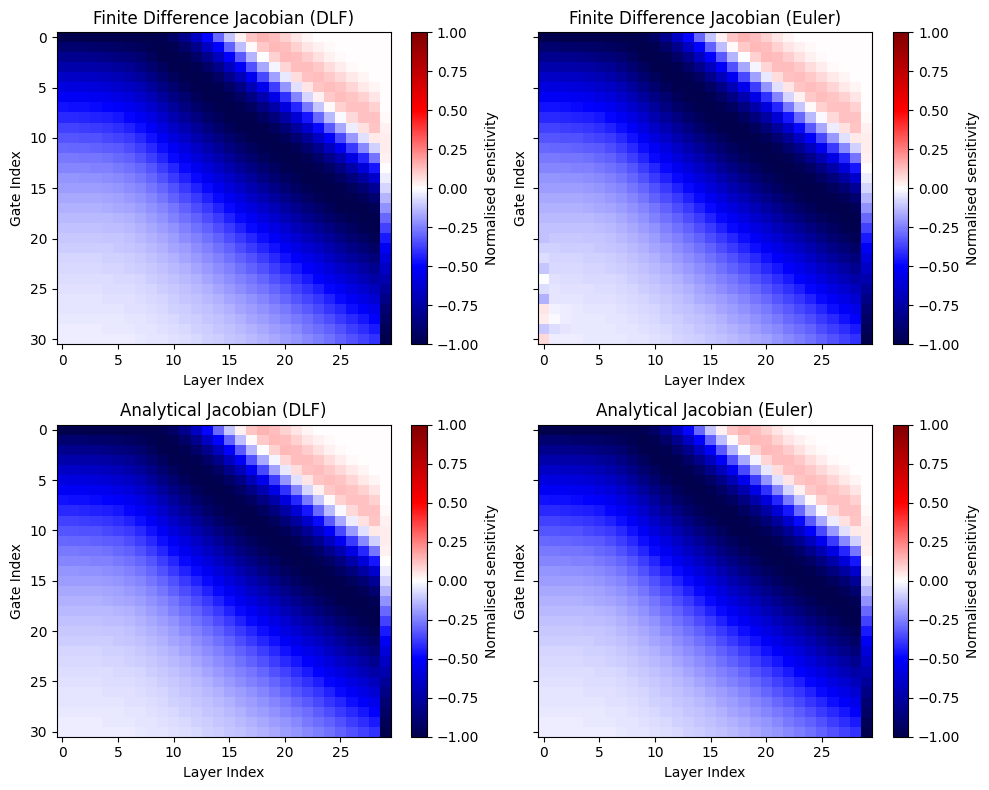

In [7]:
def _plot_jacobian(J, title, ax):
    """Plot raw Jacobian and column-normalised Jacobian side by side."""
    sens_norm = J / np.maximum(np.abs(J).max(axis=0, keepdims=True), 1e-30)
    im1 = ax.imshow(sens_norm, aspect='auto', cmap='seismic', vmin=-1, vmax=1)
    plt.colorbar(im1, ax=ax).set_label('Normalised sensitivity')
    ax.set_title(title)
    ax.set_xlabel(r'Layer Index')
    ax.set_ylabel(r'Gate Index')
    fig.tight_layout()

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
_plot_jacobian(J_fd_dlf,   'Finite Difference Jacobian (DLF)', axs[0, 0])
_plot_jacobian(J_fd_euler, 'Finite Difference Jacobian (Euler)', axs[0, 1])
_plot_jacobian(J_analytical_dlf, 'Analytical Jacobian (DLF)', axs[1, 0])
_plot_jacobian(J_analytical_euler, 'Analytical Jacobian (Euler)', axs[1, 1])

## 3. Hardware Acceleration

Even with the analytical Jacobian, the NumPy implementation still spends most of its time in Python loops: one iteration of the time loop per gate, with vectorised NumPy operations inside. Two compiled backends can push this further:

| Backend | How to enable | What it does |
|---------|---------------|--------------|
| **NumPy** (default) | — | Pure Python with vectorised array ops; works on any machine |
| **Numba JIT** | `use_numba=True` | Compiles the recursion loops to native machine code at first call; typically 5–20× faster than NumPy on CPU |
| **CuPy (GPU)** | `use_cuda=True` | Runs the entire forward+backward pass as GPU kernels; requires an NVIDIA GPU with CUDA; fastest option for large problems |

The cells below define the Numba and CuPy kernels. Both implement exactly the same adjoint Wait recursion as the NumPy version — only the execution model differs. Timing comparisons across all three backends are shown at the end of this section.


In [12]:
# ==============================================================================
# Numba JIT + GPU kernels now live in pytem.kernels_jacobian.
# getJ_analytical imported above already wires in the correct backend.
# ==============================================================================

if HAS_NUMBA:
    from pytem.kernels_jacobian import (
        _te_rte_grad_jit,
        _tem_circular_grad_jit, _tem_square_grad_jit,
        _tem_circular_grad_euler_jit, _tem_square_grad_euler_jit,
    )
    print("Numba JIT kernels loaded from pytem.kernels_jacobian")

if HAS_CUDA:
    from pytem.kernels_jacobian import (
        _te_reflection_coeff_grad_gpu,
        _tem_circular_grad_gpu, _tem_square_grad_gpu,
        _tem_circular_grad_euler_gpu, _tem_square_grad_euler_gpu,
    )
    print("GPU kernels loaded from pytem.kernels_jacobian")

# Confirm the dispatcher is available
import inspect
print("getJ_analytical params:", list(inspect.signature(getJ_analytical).parameters.keys()))


Numba JIT kernels loaded from pytem.kernels_jacobian
GPU kernels loaded from pytem.kernels_jacobian
getJ_analytical params: ['thicknesses', 'log_resistivities', 'tx_geom', 'times', 'geometry', 'rx_offset', 'rx_y', 'n_quad', 'use_symmetry', 'transform', 'hankel_filter', 'fourier_filter', 'euler_order']


In [13]:

# ============================================================
# CONFIGURATION — swap the forward model used for J timing
# ============================================================
# Set _fwd_model to any of the four options below, then re-run
# this cell and the timing cell that follows.
#
# Wrapper functions translate getJ's unified calling convention
#   fwd(thicknesses, resistivities, tx_radius, times, **kw)
# to each geometry's specific parameter signature.

_rx_offset = 10.0   # receiver offset [m]  — offset variants
_n_quad    = 5      # quadrature order      — square variants

def _wrap_circle_offset(thicknesses, resistivities, tx_radius, times, **kw):
    return fwd_circle_offset(thicknesses, resistivities, tx_radius, _rx_offset, times, **kw)

def _wrap_square_central(thicknesses, resistivities, tx_radius, times, **kw):
    # tem_forward_square supports use_numba, use_cuda, euler_order, transform, etc.
    return fwd_square_central(thicknesses, resistivities, tx_radius * np.sqrt(np.pi),
                              times, n_quad=_n_quad, **kw)

def _wrap_square_offset(thicknesses, resistivities, tx_radius, times, **kw):
    return fwd_square_offset(thicknesses, resistivities, tx_radius * np.sqrt(np.pi),
                             _rx_offset, 0.0, times, n_quad=_n_quad, **kw)

# ---- Change this line to switch model ----
_fwd_model = fwd_circle_central
#_fwd_model = _wrap_circle_offset
#_fwd_model = _wrap_square_central
# _fwd_model = _wrap_square_offset

_fwd_label = {
    fwd_circle_central:   'Circle (central)',
    _wrap_circle_offset:  f'Circle (offset  rx={_rx_offset} m)',
    _wrap_square_central: f'Square (central  n_quad={_n_quad})',
    _wrap_square_offset:  f'Square (offset  rx={_rx_offset} m  n_quad={_n_quad})',
}.get(_fwd_model, getattr(_fwd_model, '__name__', str(_fwd_model)))

# Map each forward model to the geometry string and kwargs for getJ_analytical.
_geometry_for_ana = {
    fwd_circle_central:   ('circle_central',  {}),
    _wrap_circle_offset:  ('circle_offset',   {'rx_offset': _rx_offset}),
    _wrap_square_central: ('square_central',  {'n_quad': _n_quad}),
    _wrap_square_offset:  ('square_offset',   {'rx_offset': _rx_offset, 'n_quad': _n_quad}),
}
_geometry, _ana_kwargs = _geometry_for_ana.get(_fwd_model, ('circle_central', {}))

_ana_available = True   # all four geometries support the analytical Jacobian

print(f"Forward model selected : {_fwd_label}")
print(f"Geometry key           : {_geometry}")
print(f"Analytical Jacobian    : available for all geometries")


Forward model selected : Circle (central)
Geometry key           : circle_central
Analytical Jacobian    : available for all geometries


In [53]:
from pytem.inversion import getJ, getJ_analytical
# ---- accuracy check: Ana NumPy DLF vs FD NumPy DLF -------------------------
_jcfg_dlf   = dict(hankel_filter='key_101', fourier_filter='key_81',  transform='dlf')
_jcfg_euler = dict(hankel_filter='key_101', euler_order=11,            transform='euler')

print(f"Accuracy check ({_fwd_label}) ...")
J_fd_ref = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
                tx_geom=a, times=times, fwd=_fwd_model,
                use_numba=False, use_cuda=False, **_jcfg_dlf)

J_ana_ref = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                             tx_geom=a, times=times, geometry=_geometry,
                             use_numba=False, use_cuda=False,
                             **_ana_kwargs, **_jcfg_dlf)

denom = np.abs(J_fd_ref)
denom[denom < 1e-30] = 1e-30
rel_err = np.abs(J_ana_ref - J_fd_ref) / denom
print(f"  Ana NumPy DLF vs FD NumPy DLF  max rel. error = {rel_err.max():.2e}  "
      f"mean (non-zero) = {rel_err[np.abs(J_fd_ref) > 1e-10].mean():.2e}")

# ---- timing -----------------------------------------------------------------
# Keys are (method, transform, backend) tuples so no backslash in f-strings.
# method: 'FD' or 'Ana'  |  transform: 'DLF' or 'Euler'  |  backend: 'NumPy','Numba','CUDA'

timing = {}   # (method, transform, backend) -> seconds

# NumPy baselines
print("\nTiming NumPy baselines ...")
timing[('Finite Diff.',  'DLF',   'NumPy')] = benchmark(lambda: getJ(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_geom=a, times=times, fwd=_fwd_model,
    use_numba=False, use_cuda=False, **_jcfg_dlf))

timing[('Finite Diff.',  'Euler', 'NumPy')] = benchmark(lambda: getJ(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_geom=a, times=times, fwd=_fwd_model,
    use_numba=False, use_cuda=False, **_jcfg_euler))

timing[('Analytical', 'DLF',   'NumPy')] = benchmark(lambda: getJ_analytical(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_geom=a, times=times, geometry=_geometry,
    use_numba=False, use_cuda=False, **_ana_kwargs, **_jcfg_dlf))

timing[('Analytical', 'Euler', 'NumPy')] = benchmark(lambda: getJ_analytical(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_geom=a, times=times, geometry=_geometry,
    use_numba=False, use_cuda=False, **_ana_kwargs, **_jcfg_euler))

for (m, tr, be), v in timing.items():
    print(f"  {m:3s} {tr:5s} {be:5s}: {v*1000:.1f} ms")

# Numba (warm up first so JIT cost is excluded)
if HAS_NUMBA:
    print("\nWarming up Numba ...")
    getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
         tx_geom=a, times=times, fwd=_fwd_model,
         use_numba=True, use_cuda=False, **_jcfg_dlf)
    getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                    tx_geom=a, times=times, geometry=_geometry,
                    use_numba=True, use_cuda=False, **_ana_kwargs, **_jcfg_dlf)
    print("Timing Numba ...")
    timing[('Finite Diff.',  'DLF',   'Numba')] = benchmark(lambda: getJ(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, fwd=_fwd_model,
        use_numba=True, use_cuda=False, **_jcfg_dlf))
    timing[('Finite Diff.',  'Euler', 'Numba')] = benchmark(lambda: getJ(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, fwd=_fwd_model,
        use_numba=True, use_cuda=False, **_jcfg_euler))
    timing[('Analytical', 'DLF',   'Numba')] = benchmark(lambda: getJ_analytical(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, geometry=_geometry,
        use_numba=True, use_cuda=False, **_ana_kwargs, **_jcfg_dlf))
    timing[('Analytical', 'Euler', 'Numba')] = benchmark(lambda: getJ_analytical(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, geometry=_geometry,
        use_numba=True, use_cuda=False, **_ana_kwargs, **_jcfg_euler))
    for k in [('Finite Diff.', 'DLF', 'Numba'), ('Finite Diff.', 'Euler', 'Numba'),
              ('Analytical', 'DLF', 'Numba'), ('Analytical', 'Euler', 'Numba')]:
        m, tr, be = k
        print(f"  {m:3s} {tr:5s} {be:5s}: {timing[k]*1000:.1f} ms")

# CUDA
if HAS_CUDA:
    print("\nWarming up CUDA ...")
    getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
         tx_geom=a, times=times, fwd=_fwd_model,
         use_numba=False, use_cuda=True, **_jcfg_dlf)
    getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                    tx_geom=a, times=times, geometry=_geometry,
                    use_numba=False, use_cuda=True, **_ana_kwargs, **_jcfg_dlf)
    print("Timing CUDA ...")
    timing[('Finite Diff.',  'DLF',   'CUDA')] = benchmark(lambda: getJ(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, fwd=_fwd_model,
        use_numba=False, use_cuda=True, **_jcfg_dlf))
    timing[('Finite Diff.',  'Euler', 'CUDA')] = benchmark(lambda: getJ(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, fwd=_fwd_model,
        use_numba=False, use_cuda=True, **_jcfg_euler))
    timing[('Analytical', 'DLF',   'CUDA')] = benchmark(lambda: getJ_analytical(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, geometry=_geometry,
        use_numba=False, use_cuda=True, **_ana_kwargs, **_jcfg_dlf))
    timing[('Analytical', 'Euler', 'CUDA')] = benchmark(lambda: getJ_analytical(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, geometry=_geometry,
        use_numba=False, use_cuda=True, **_ana_kwargs, **_jcfg_euler))
    for k in [('Finite Diff.', 'DLF', 'CUDA'), ('Finite Diff.', 'Euler', 'CUDA'),
              ('Analytical', 'DLF', 'CUDA'), ('Analytical', 'Euler', 'CUDA')]:
        m, tr, be = k
        print(f"  {m:3s} {tr:5s} {be:5s}: {timing[k]*1000:.1f} ms")


Accuracy check (Circle (central)) ...
  Ana NumPy DLF vs FD NumPy DLF  max rel. error = 4.46e-02  mean (non-zero) = 2.74e-04

Timing NumPy baselines ...
  Finite Diff. DLF   NumPy: 26318.1 ms
  Finite Diff. Euler NumPy: 7418.3 ms
  Analytical DLF   NumPy: 1067.1 ms
  Analytical Euler NumPy: 614.6 ms

Warming up Numba ...
Timing Numba ...
  Finite Diff. DLF   Numba: 5631.2 ms
  Finite Diff. Euler Numba: 2720.9 ms
  Analytical DLF   Numba: 923.9 ms
  Analytical Euler Numba: 263.9 ms

Warming up CUDA ...
Timing CUDA ...
  Finite Diff. DLF   CUDA : 1919.0 ms
  Finite Diff. Euler CUDA : 612.6 ms
  Analytical DLF   CUDA : 346.8 ms
  Analytical Euler CUDA : 104.5 ms


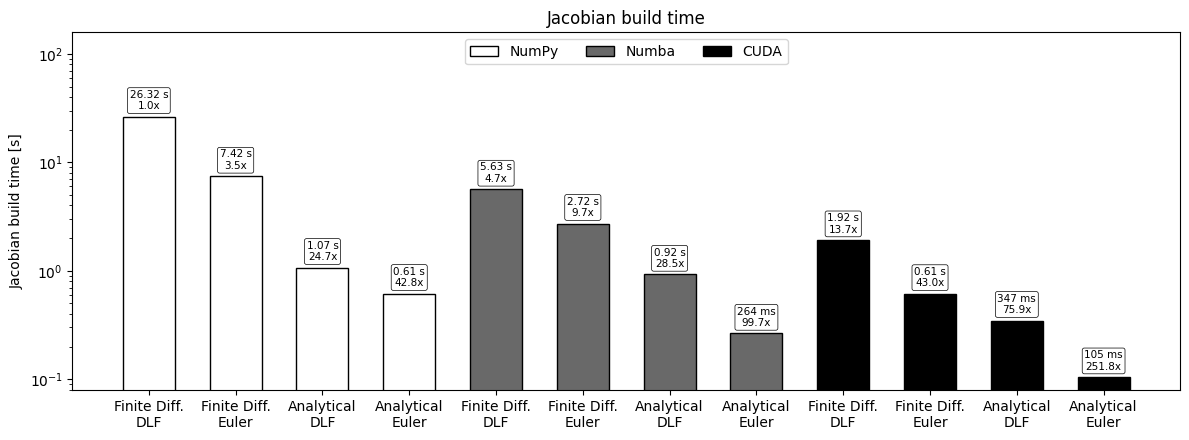

In [58]:
from matplotlib import patches
_colour_map = {'NumPy': 'white', 'Numba': 'dimgray', 'CUDA': 'black'}

keys       = list(timing.keys())
vals       = [timing[k] for k in keys]
tick_labels = [k[0] + '\n' + k[1] for k in keys]
colours     = [_colour_map[k[2]] for k in keys]
x           = np.arange(len(keys))

ref = timing[('Finite Diff.', 'DLF', 'NumPy')]

fig, ax = plt.subplots(figsize=(max(7, len(keys) * 1), 4.5))
bars = ax.bar(x, vals, color=colours, edgecolor='black', width=0.6)
for bar, val in zip(bars, vals):
    speedup = ref / val
    time_label = f"{val:.2f} s" if val >= 0.5 else f"{val*1000:.0f} ms"
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.12,
            f"{time_label}\n{speedup:.1f}x",
            ha='center', va='bottom', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='black', lw=0.5))

ax.set_xticks(x)
ax.set_xticklabels(tick_labels)

legend_handles = [
    patches.Patch(facecolor='white',   edgecolor='black', label='NumPy'),
    patches.Patch(facecolor='dimgray', edgecolor='black', label='Numba'),
    patches.Patch(facecolor='black',   edgecolor='black', label='CUDA'),
]
ax.legend(handles=legend_handles, ncol=3, loc='upper center')
ax.set_ylabel('Jacobian build time [s]')
ax.set_title('Jacobian build time')
ax.set_yscale('log')
ax.set_ylim(None, np.ceil(max(vals) * 6))
fig.tight_layout()
plt.show()
